# German Electricity Market: Explaining and Forecasting Day-Ahead Power Prices

### Research Question

How are electricity demand and renewable generation associated with German
day-ahead electricity prices, and can these variables help predict short-term
price movements?

### Scope

This analysis uses 15-minute German electricity market data from January 1
through September 13, 2026.

The analysis covers:
- Exploratory analysis of electricity demand, renewable generation, and price
- Feature engineering and lag selection
- Linear regression forecasting
- Gradient Boosting forecasting and hyperparameter tuning
- Error analysis across different price regimes

In [1]:
import pandas as pd
import requests
print("set up working")
import matplotlib.pyplot as plt

set up working


In [2]:
price_url = "https://api.energy-charts.info/price"

price_params = {
    "country": "de",
    "start": "2026-01-01",
    "end": "2026-09-13"
}

price_response = requests.get(price_url, params=price_params)



In [3]:
print(price_response.status_code)

price_data = price_response.json()

print(price_data.keys())


200
dict_keys(['license_info', 'unix_seconds', 'price', 'unit', 'deprecated'])


In [4]:
price_df_timestamp = pd.to_datetime(
    price_data["unix_seconds"], unit="s", utc=True
).tz_convert("Europe/Berlin")

In [5]:
price_df = pd.DataFrame({
    "timestamp": price_df_timestamp ,
    "price": price_data["price"]
})

In [6]:
print(price_df.head())
print(price_df.shape)

                  timestamp  price
0 2026-01-01 00:00:00+01:00  63.64
1 2026-01-01 00:15:00+01:00  61.48
2 2026-01-01 00:30:00+01:00  58.00
3 2026-01-01 00:45:00+01:00  49.99
4 2026-01-01 01:00:00+01:00  60.01
(24572, 2)


In [7]:
local_diff = price_df["timestamp"].dt.tz_localize(None).diff()
print(local_diff.value_counts())

timestamp
0 days 00:15:00    24570
0 days 01:15:00        1
Name: count, dtype: int64


#### Data-quality note: daylight-saving time

The dataset uses Europe/Berlin local time. During the daylight-saving transition, four expected 15-minute local timestamps do not occur. This produces one 1-hour-15-minute gap in the naive local-time sequence.

This is a calendar/time-zone effect, not ordinary missing data, so the observations were not imputed or removed.

In [8]:
url = "https://api.energy-charts.info/v2/public_power"

params = {
    "country": "de",
    "start": "2026-01-01",
    "end": "2026-09-13"
}

power_response = requests.get(url, params=params)
power_data = power_response.json()

print(power_response.status_code)
print(power_data.keys())

200
dict_keys(['schema_version', 'endpoint', 'country', 'bidding_zone', 'timezone', 'resolution', 'interval_minutes', 'unit', 'generated_at', 'available_from', 'available_until', 'series', 'data', 'attributes', 'license', 'deprecated'])


In [9]:

print(power_data["series"])
print(power_data["data"][0])

[{'id': 'hydro_pumped_storage_consumption', 'name': 'Hydro pumped storage consumption'}, {'id': 'cross_border_electricity_trading', 'name': 'Cross border electricity trading'}, {'id': 'hydro_run_of_river', 'name': 'Hydro Run-of-River'}, {'id': 'biomass', 'name': 'Biomass'}, {'id': 'fossil_brown_coal_lignite', 'name': 'Fossil brown coal / lignite'}, {'id': 'fossil_hard_coal', 'name': 'Fossil hard coal'}, {'id': 'fossil_oil', 'name': 'Fossil oil'}, {'id': 'fossil_coal_derived_gas', 'name': 'Fossil coal-derived gas'}, {'id': 'fossil_gas', 'name': 'Fossil gas'}, {'id': 'geothermal', 'name': 'Geothermal'}, {'id': 'hydro_water_reservoir', 'name': 'Hydro water reservoir'}, {'id': 'hydro_pumped_storage', 'name': 'Hydro pumped storage'}, {'id': 'others', 'name': 'Others'}, {'id': 'waste', 'name': 'Waste'}, {'id': 'wind_offshore', 'name': 'Wind offshore'}, {'id': 'wind_onshore', 'name': 'Wind onshore'}, {'id': 'solar', 'name': 'Solar'}, {'id': 'load', 'name': 'Load'}, {'id': 'residual_load', 'na

In [10]:
rows = []

for row in power_data["data"]:
    rows.append({
        "timestamp": row["timestamp"],
        "load": row["values"].get("load"),
        "wind_onshore": row["values"].get("wind_onshore"),
        "solar": row["values"].get("solar")
    })

power_df = pd.DataFrame(rows)

In [11]:
power_df["timestamp"] = pd.to_datetime(
    power_df["timestamp"],
    utc=True
).dt.tz_convert("Europe/Berlin")

In [12]:
print(power_df["timestamp"].min(), power_df["timestamp"].max())
print(price_df["timestamp"].min(), price_df["timestamp"].max())

2026-01-01 00:00:00+01:00 2026-09-13 23:45:00+02:00
2026-01-01 00:00:00+01:00 2026-09-13 23:45:00+02:00


In [13]:
print(power_df.head())
print(power_df.shape)

                  timestamp     load  wind_onshore  solar
0 2026-01-01 00:00:00+01:00  46427.4       31462.6    0.0
1 2026-01-01 00:15:00+01:00  46085.1       31849.2    0.0
2 2026-01-01 00:30:00+01:00  46038.6       32711.4    0.0
3 2026-01-01 00:45:00+01:00  45940.4       33195.1    0.0
4 2026-01-01 01:00:00+01:00  45656.0       33481.0    0.0
(24572, 4)


In [14]:
print(power_df["timestamp"].equals(price_df["timestamp"]))

True


In [15]:
print(power_df["timestamp"].dtype)
print(price_df["timestamp"].dtype)

datetime64[ns, Europe/Berlin]
datetime64[ns, Europe/Berlin]


In [16]:
merged_df = power_df.merge(price_df, on="timestamp", how="inner")

print(merged_df.head())
print(merged_df.shape)

                  timestamp     load  wind_onshore  solar  price
0 2026-01-01 00:00:00+01:00  46427.4       31462.6    0.0  63.64
1 2026-01-01 00:15:00+01:00  46085.1       31849.2    0.0  61.48
2 2026-01-01 00:30:00+01:00  46038.6       32711.4    0.0  58.00
3 2026-01-01 00:45:00+01:00  45940.4       33195.1    0.0  49.99
4 2026-01-01 01:00:00+01:00  45656.0       33481.0    0.0  60.01
(24572, 5)


In [17]:
print(merged_df.isna().sum())

timestamp       0
load            0
wind_onshore    0
solar           0
price           0
dtype: int64


In [18]:
print(merged_df["timestamp"].duplicated().sum())

0


In [19]:
print(merged_df.dtypes)

timestamp       datetime64[ns, Europe/Berlin]
load                                  float64
wind_onshore                          float64
solar                                 float64
price                                 float64
dtype: object


In [20]:
merged_df.describe()

,load,wind_onshore,solar,price
count,24572.000000,24572.000000,24572.000000,24572.000000
mean,52964.910667,11837.671264,11622.087213,104.995103
std,9175.271446,8739.473117,15842.673407,64.545605
min,32445.500000,63.900000,0.000000,-499.990000
25%,45494.100000,4911.750000,0.000000,80.527500
50%,53036.050000,9871.300000,1313.400000,110.685000
75%,58826.775000,16854.750000,22058.100000,140.815000
max,78372.600000,47300.000000,58507.000000,747.100000


In [21]:
print((merged_df["price"] < 0).sum())

1784


##### Data Quality Notes
- No missing values were found in the merged dataset.
- No duplicate timestamps were found.
- The dataset uses Europe/Berlin local time and contains one daylight-saving transition, producing a 1-hour-15-minute gap in the naive local-time sequence. This was treated as a timezone/calendar effect rather than imputed missing data.
- Negative electricity prices were retained because they are valid market observations.

## EDA


In [22]:
merged_df[["load", "wind_onshore", "solar", "price"]].describe()

,load,wind_onshore,solar,price
count,24572.000000,24572.000000,24572.000000,24572.000000
mean,52964.910667,11837.671264,11622.087213,104.995103
std,9175.271446,8739.473117,15842.673407,64.545605
min,32445.500000,63.900000,0.000000,-499.990000
25%,45494.100000,4911.750000,0.000000,80.527500
50%,53036.050000,9871.300000,1313.400000,110.685000
75%,58826.775000,16854.750000,22058.100000,140.815000
max,78372.600000,47300.000000,58507.000000,747.100000


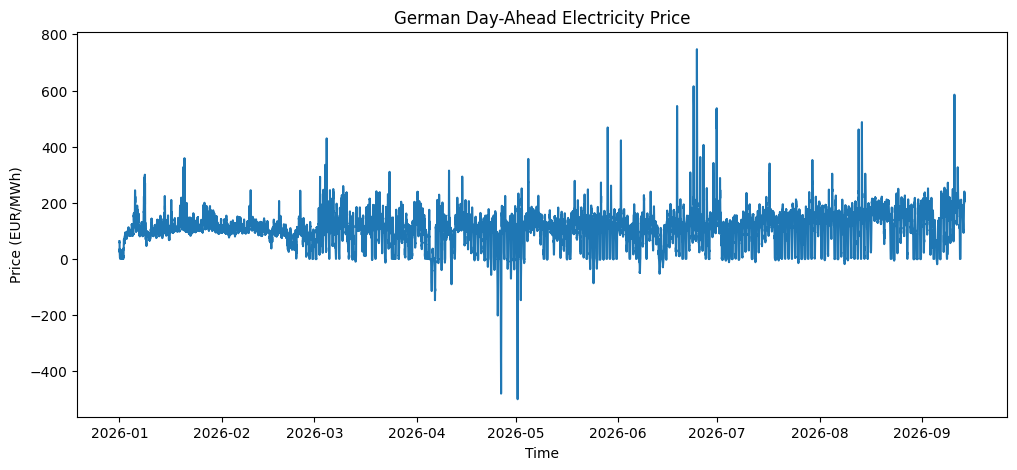

In [23]:
plt.figure(figsize=(12, 5))
plt.plot(merged_df["timestamp"], merged_df["price"])
plt.xlabel("Time")
plt.ylabel("Price (EUR/MWh)")
plt.title("German Day-Ahead Electricity Price")
plt.show()

In [24]:
merged_df[["load", "wind_onshore", "solar", "price"]].corr()

,load,wind_onshore,solar,price
load,1.000000,0.141103,0.103184,0.108615
wind_onshore,0.141103,1.000000,-0.294683,-0.229890
solar,0.103184,-0.294683,1.000000,-0.585808
price,0.108615,-0.229890,-0.585808,1.000000


In [25]:
merged_df["renewable_generation"] = (
    merged_df["wind_onshore"] + merged_df["solar"]
)

print(
    merged_df[["renewable_generation", "load", "price"]].corr()
)

                      renewable_generation      load     price
renewable_generation              1.000000  0.182936 -0.720158
load                              0.182936  1.000000  0.108615
price                            -0.720158  0.108615  1.000000


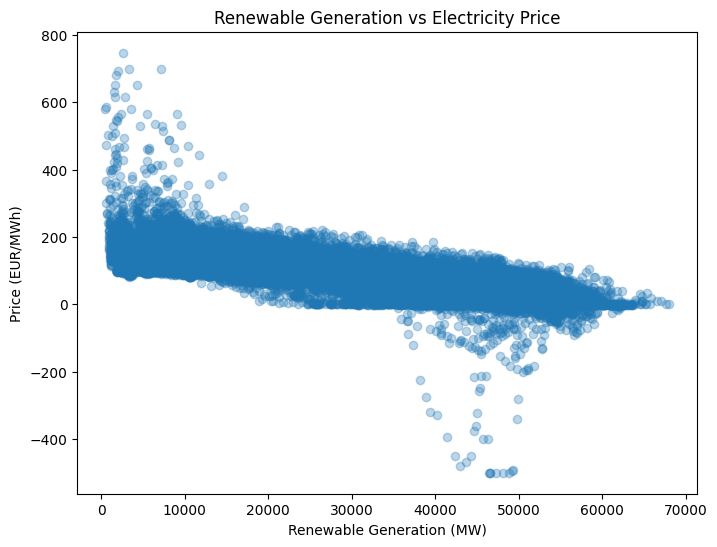

In [26]:
plt.figure(figsize=(8, 6))
plt.scatter(
    merged_df["renewable_generation"],
    merged_df["price"],
    alpha=0.3
)
plt.xlabel("Renewable Generation (MW)")
plt.ylabel("Price (EUR/MWh)")
plt.title("Renewable Generation vs Electricity Price")
plt.show()

In [27]:
merged_df["hour"] = merged_df["timestamp"].dt.hour
hourly_corr = (
    merged_df.groupby("hour")[["renewable_generation", "load", "price"]]
    .corr()
)

print(hourly_corr)

                           renewable_generation      load     price
hour                                                               
0    renewable_generation              1.000000  0.242801 -0.715164
     load                              0.242801  1.000000 -0.375899
     price                            -0.715164 -0.375899  1.000000
1    renewable_generation              1.000000  0.244398 -0.725586
     load                              0.244398  1.000000 -0.349356
...                                         ...       ...       ...
22   load                              0.260757  1.000000 -0.307928
     price                            -0.593254 -0.307928  1.000000
23   renewable_generation              1.000000  0.265307 -0.666173
     load                              0.265307  1.000000 -0.411312
     price                            -0.666173 -0.411312  1.000000

[72 rows x 3 columns]


In [28]:
hourly_price_corr = (
    hourly_corr.xs("price", level=1)[["renewable_generation", "load"]]
)

print(hourly_price_corr)

      renewable_generation      load
hour                                
0                -0.715164 -0.375899
1                -0.725586 -0.349356
2                -0.747154 -0.341109
3                -0.762641 -0.335934
4                -0.767529 -0.322010
5                -0.734277 -0.190457
6                -0.662942  0.101421
7                -0.610469  0.298373
8                -0.609388  0.438781
9                -0.641391  0.576895
10               -0.673570  0.634381
11               -0.687464  0.673360
12               -0.638631  0.667519
13               -0.567562  0.643155
14               -0.582748  0.647820
15               -0.670359  0.680865
16               -0.721605  0.636854
17               -0.722274  0.511905
18               -0.712480  0.233082
19               -0.567700 -0.076226
20               -0.558668 -0.180026
21               -0.563858 -0.210785
22               -0.593254 -0.307928
23               -0.666173 -0.411312


##### EDA Findings

- Renewable generation showed a strong negative linear association with day-ahead electricity price (r = -0.72).
- Overall load-price correlation was weakly positive (r = 0.11).
- The load-price relationship varied substantially by hour of day.
- The negative renewable-price association remained present when correlations were calculated separately by hour.
- Electricity price showed substantial volatility, including negative-price observations.

## Statistical Modeling

The target variable is electricity price. Predictor variables are load, wind generation, solar generation, and cyclical hour features.

A multiple linear regression model will be used first as a baseline to quantify the association between these predictors and electricity price.

In [29]:
import numpy as np

merged_df["hour_sin"] = np.sin(2 * np.pi * merged_df["hour"] / 24)
merged_df["hour_cos"] = np.cos(2 * np.pi * merged_df["hour"] / 24)

In [30]:
print(merged_df[["hour", "hour_sin", "hour_cos"]].head())

   hour  hour_sin  hour_cos
0     0  0.000000  1.000000
1     0  0.000000  1.000000
2     0  0.000000  1.000000
3     0  0.000000  1.000000
4     1  0.258819  0.965926


In [31]:
X = merged_df[
    ["load", "wind_onshore", "solar", "hour_sin", "hour_cos"]
]

y = merged_df["price"]

print(X.head())
print(y.head())

      load  wind_onshore  solar  hour_sin  hour_cos
0  46427.4       31462.6    0.0  0.000000  1.000000
1  46085.1       31849.2    0.0  0.000000  1.000000
2  46038.6       32711.4    0.0  0.000000  1.000000
3  45940.4       33195.1    0.0  0.000000  1.000000
4  45656.0       33481.0    0.0  0.258819  0.965926
0    63.64
1    61.48
2    58.00
3    49.99
4    60.01
Name: price, dtype: float64


In [32]:
split_index = int(len(X) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(19657, 5) (4915, 5)
(19657,) (4915,)


In [33]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](5,)","[ 0. ,-0. ,-0. ,-5.4 , 8.87]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](5,)","['load','wind_onshore','solar','hour_sin','hour_cos']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,47.7
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(5)


In [34]:
print(model.coef_)
print(model.intercept_)

[ 2.32038307e-03 -3.61396865e-03 -2.75318823e-03 -5.40216988e+00
  8.87007264e+00]
47.6964950913314


In [35]:
y_pred = model.predict(X_test)

In [36]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 48.785512580511664
RMSE: 57.16708154883393
R²: 0.3109865548659372


In [37]:
baseline_pred = merged_df["price"].shift(1).loc[y_test.index]

baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_rmse = mean_squared_error(y_test, baseline_pred) ** 0.5

print("Baseline MAE:", baseline_mae)
print("Baseline RMSE:", baseline_rmse)

Baseline MAE: 8.955511698880978
Baseline RMSE: 14.015047861187394


##### Baseline Comparison
A naive persistence baseline was evaluated by predicting each 15-minute price using the previous observed price.

The baseline substantially outperformed the initial linear regression model:

- Linear regression MAE: 48.78 EUR/MWh
- Baseline MAE: 8.96 EUR/MWh
- Linear regression RMSE: 57.16 EUR/MWh
- Baseline RMSE: 14.02 EUR/MWh

This indicates strong short-term price persistence and motivates the use of lagged price features in subsequent forecasting models.

In [38]:
merged_df["price_lag_1"] = merged_df["price"].shift(1)

In [39]:
print(merged_df[["timestamp", "price", "price_lag_1"]].head())

                  timestamp  price  price_lag_1
0 2026-01-01 00:00:00+01:00  63.64          NaN
1 2026-01-01 00:15:00+01:00  61.48        63.64
2 2026-01-01 00:30:00+01:00  58.00        61.48
3 2026-01-01 00:45:00+01:00  49.99        58.00
4 2026-01-01 01:00:00+01:00  60.01        49.99


In [40]:
model_df = merged_df.dropna(subset=["price_lag_1"]).copy()

In [41]:
X_lag = model_df[
    ["load", "wind_onshore", "solar", "hour_sin", "hour_cos", "price_lag_1"]
]

y_lag = model_df["price"]

split_index = int(len(X_lag) * 0.8)

X_train_lag = X_lag.iloc[:split_index]
X_test_lag = X_lag.iloc[split_index:]

y_train_lag = y_lag.iloc[:split_index]
y_test_lag = y_lag.iloc[split_index:]

print(X_train_lag.shape, X_test_lag.shape)

(19656, 6) (4915, 6)


In [42]:
lag_model = LinearRegression()
lag_model.fit(X_train_lag, y_train_lag)

y_pred_lag = lag_model.predict(X_test_lag)

lag_mae = mean_absolute_error(y_test_lag, y_pred_lag)
lag_rmse = mean_squared_error(y_test_lag, y_pred_lag) ** 0.5
lag_r2 = r2_score(y_test_lag, y_pred_lag)

print("Lag model MAE:", lag_mae)
print("Lag model RMSE:", lag_rmse)
print("Lag model R²:", lag_r2)

Lag model MAE: 8.73872934010108
Lag model RMSE: 13.5245738204315
Lag model R²: 0.9614359327899632


In [43]:
model_df = merged_df.copy()

model_df["price_lag_1"] = model_df["price"].shift(1)
model_df["price_lag_2"] = model_df["price"].shift(2)
model_df["price_lag_4"] = model_df["price"].shift(4)
model_df["price_lag_96"] = model_df["price"].shift(96)
model_df["price_lag_672"] = model_df["price"].shift(672)

model_df = model_df.dropna(
    subset=[
        "price_lag_1",
        "price_lag_2",
        "price_lag_4",
        "price_lag_96",
        "price_lag_672"
    ]
).copy()

print(model_df.shape)

(23900, 14)


In [44]:
X_lag672 = model_df[
    ["load", "wind_onshore", "solar",
     "hour_sin", "hour_cos",
     "price_lag_1", "price_lag_2", "price_lag_4",
     "price_lag_96", "price_lag_672"]
]

y_lag672 = model_df["price"]

split_index = int(len(X_lag672) * 0.8)

X_train_lag672 = X_lag672.iloc[:split_index]
X_test_lag672 = X_lag672.iloc[split_index:]

y_train_lag672 = y_lag672.iloc[:split_index]
y_test_lag672 = y_lag672.iloc[split_index:]

print(X_train_lag672.shape, X_test_lag672.shape)

(19120, 10) (4780, 10)


In [45]:
lag672_model = LinearRegression()
lag672_model.fit(X_train_lag672, y_train_lag672)

y_pred_lag672 = lag672_model.predict(X_test_lag672)

mae_lag672 = mean_absolute_error(y_test_lag672, y_pred_lag672)
rmse_lag672 = mean_squared_error(y_test_lag672, y_pred_lag672) ** 0.5
r2_lag672 = r2_score(y_test_lag672, y_pred_lag672)

print("MAE:", mae_lag672)
print("RMSE:", rmse_lag672)
print("R²:", r2_lag672)

MAE: 8.569033739857561
RMSE: 13.18218816388223
R²: 0.9631337168174486


In [46]:
common_df = merged_df.copy()

common_df["price_lag_1"] = common_df["price"].shift(1)
common_df["price_lag_2"] = common_df["price"].shift(2)
common_df["price_lag_4"] = common_df["price"].shift(4)
common_df["price_lag_96"] = common_df["price"].shift(96)
common_df["price_lag_672"] = common_df["price"].shift(672)

common_df = common_df.dropna(
    subset=[
        "price_lag_1",
        "price_lag_2",
        "price_lag_4",
        "price_lag_96",
        "price_lag_672"
    ]
).copy()

print(common_df.shape)

(23900, 14)


In [47]:
common_split = int(len(common_df) * 0.8)

common_train = common_df.iloc[:common_split]
common_test = common_df.iloc[common_split:]

print(common_train.shape)
print(common_test.shape)

(19120, 14)
(4780, 14)


In [48]:
features_1lag = [
    "load", "wind_onshore", "solar",
    "hour_sin", "hour_cos",
    "price_lag_1"
]

X_train_1lag = common_train[features_1lag]
X_test_1lag = common_test[features_1lag]

y_train_common = common_train["price"]
y_test_common = common_test["price"]

model_1lag = LinearRegression()
model_1lag.fit(X_train_1lag, y_train_common)

pred_1lag = model_1lag.predict(X_test_1lag)

mae_1lag = mean_absolute_error(y_test_common, pred_1lag)
rmse_1lag = mean_squared_error(y_test_common, pred_1lag) ** 0.5
r2_1lag = r2_score(y_test_common, pred_1lag)

print("MAE:", mae_1lag)
print("RMSE:", rmse_1lag)
print("R²:", r2_1lag)

MAE: 8.78519232446852
RMSE: 13.55183486755126
R²: 0.9610371654992248


In [49]:
features_24lag = features_1lag + ["price_lag_96"]

X_train_24lag = common_train[features_24lag]
X_test_24lag = common_test[features_24lag]

model_24lag = LinearRegression()
model_24lag.fit(X_train_24lag, y_train_common)

pred_24lag = model_24lag.predict(X_test_24lag)

mae_24lag = mean_absolute_error(y_test_common, pred_24lag)
rmse_24lag = mean_squared_error(y_test_common, pred_24lag) ** 0.5
r2_24lag = r2_score(y_test_common, pred_24lag)

print("MAE:", mae_24lag)
print("RMSE:", rmse_24lag)
print("R²:", r2_24lag)

MAE: 8.665194716182478
RMSE: 13.270036844480828
R²: 0.9626407112847128


In [50]:
features_3lag = features_24lag + ["price_lag_2", "price_lag_4"]

X_train_3lag = common_train[features_3lag]
X_test_3lag = common_test[features_3lag]

model_3lag = LinearRegression()
model_3lag.fit(X_train_3lag, y_train_common)

pred_3lag = model_3lag.predict(X_test_3lag)

mae_3lag = mean_absolute_error(y_test_common, pred_3lag)
rmse_3lag = mean_squared_error(y_test_common, pred_3lag) ** 0.5
r2_3lag = r2_score(y_test_common, pred_3lag)

print("MAE:", mae_3lag)
print("RMSE:", rmse_3lag)
print("R²:", r2_3lag)

MAE: 8.650977311190461
RMSE: 13.296939016664991
R²: 0.9624890817470089


In [51]:
features_weekly = features_24lag + ["price_lag_672"]

X_train_weekly = common_train[features_weekly]
X_test_weekly = common_test[features_weekly]

model_weekly = LinearRegression()
model_weekly.fit(X_train_weekly, y_train_common)

pred_weekly = model_weekly.predict(X_test_weekly)

mae_weekly = mean_absolute_error(y_test_common, pred_weekly)
rmse_weekly = mean_squared_error(y_test_common, pred_weekly) ** 0.5
r2_weekly = r2_score(y_test_common, pred_weekly)

print("MAE:", mae_weekly)
print("RMSE:", rmse_weekly)
print("R²:", r2_weekly)

MAE: 8.575458187276844
RMSE: 13.147734056919095
R²: 0.9633261787824522


In [52]:
common_df = merged_df.copy()

common_df["price_lag_1"] = common_df["price"].shift(1)
common_df["price_lag_2"] = common_df["price"].shift(2)
common_df["price_lag_4"] = common_df["price"].shift(4)
common_df["price_lag_96"] = common_df["price"].shift(96)
common_df["price_lag_672"] = common_df["price"].shift(672)

common_df["day_of_week"] = common_df["timestamp"].dt.dayofweek
common_df["month"] = common_df["timestamp"].dt.month

day_dummies = pd.get_dummies(
    common_df["day_of_week"],
    prefix="day",
    drop_first=True,
    dtype=int
)

month_dummies = pd.get_dummies(
    common_df["month"],
    prefix="month",
    drop_first=True,
    dtype=int
)

common_df = pd.concat(
    [common_df, day_dummies, month_dummies],
    axis=1
)

print(common_df.shape)

(24572, 30)


In [53]:
lag1_df = common_df.dropna(
    subset=["price_lag_1"]
).copy()

In [54]:
features_lag1 = [
    "load",
    "wind_onshore",
    "solar",
    "hour_sin",
    "hour_cos",
    "price_lag_1"
]

X_lag1 = lag1_df[features_lag1]
y_lag1 = lag1_df["price"]

In [55]:
split_index = int(len(lag1_df) * 0.8)

X_train_lag1 = X_lag1.iloc[:split_index]
X_test_lag1 = X_lag1.iloc[split_index:]

y_train_lag1 = y_lag1.iloc[:split_index]
y_test_lag1 = y_lag1.iloc[split_index:]

In [56]:
model_lag1 = LinearRegression()

model_lag1.fit(X_train_lag1, y_train_lag1)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](6,)","[-0. ,-0. ,-0. ,-3.43,-3.88, 0.93]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](6,)","['load','wind_onshore','solar','hour_sin','hour_cos','price_lag_1']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,16.08
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,6
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(6)


In [57]:
y_pred_lag1 = model_lag1.predict(X_test_lag1)

mae_lag1 = mean_absolute_error(y_test_lag1, y_pred_lag1)
rmse_lag1 = np.sqrt(mean_squared_error(y_test_lag1, y_pred_lag1))
r2_lag1 = r2_score(y_test_lag1, y_pred_lag1)

print("Lag 1 Model")
print("MAE:", mae_lag1)
print("RMSE:", rmse_lag1)
print("R²:", r2_lag1)

Lag 1 Model
MAE: 8.73872934010108
RMSE: 13.5245738204315
R²: 0.9614359327899632


In [58]:
lag_short_df = common_df.dropna(
    subset=["price_lag_1", "price_lag_2", "price_lag_4"]
).copy()

In [59]:
features_short_lags = [
    "load",
    "wind_onshore",
    "solar",
    "hour_sin",
    "hour_cos",
    "price_lag_1",
    "price_lag_2",
    "price_lag_4"
]
X_lag_short = lag_short_df[features_short_lags]
y_lag_short = lag_short_df["price"]

In [60]:
split_index = int(len(lag_short_df) * 0.8)

X_train_lag_short = X_lag_short.iloc[:split_index]
X_test_lag_short = X_lag_short.iloc[split_index:]

y_train_lag_short = y_lag_short.iloc[:split_index]
y_test_lag_short = y_lag_short.iloc[split_index:]

In [61]:
model_lag_short = LinearRegression()

model_lag_short.fit(X_train_lag_short, y_train_lag_short)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](8,)","[-0. ,-0. ,-0. ,..., 0.86, 0.06, 0.01]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](8,)","['load','wind_onshore','solar',...,'price_lag_1','price_lag_2', 'price_lag_4']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,16.78
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(8)


In [62]:
y_pred_lag_short = model_lag_short.predict(X_test_lag_short)

mae_lag_short = mean_absolute_error(y_test_lag_short, y_pred_lag_short)
rmse_lag_short = np.sqrt(mean_squared_error(y_test_lag_short, y_pred_lag_short))
r2_lag_short = r2_score(y_test_lag_short, y_pred_lag_short)

print("Short Lag Model")
print("MAE:", mae_lag_short)
print("RMSE:", rmse_lag_short)
print("R²:", r2_lag_short)

Short Lag Model
MAE: 8.71507433031685
RMSE: 13.529944133607103
R²: 0.9614093291415376


In [63]:
common_lag_df = common_df.dropna(
    subset=["price_lag_1", "price_lag_2", "price_lag_4"]
).copy()

split_index = int(len(common_lag_df) * 0.8)

train_df = common_lag_df.iloc[:split_index]
test_df = common_lag_df.iloc[split_index:]

In [64]:
features_lag1 = [
    "load",
    "wind_onshore",
    "solar",
    "hour_sin",
    "hour_cos",
    "price_lag_1"
]

model_lag1_fair = LinearRegression()

model_lag1_fair.fit(
    train_df[features_lag1],
    train_df["price"]
)

pred_lag1_fair = model_lag1_fair.predict(
    test_df[features_lag1]
)

mae_lag1_fair = mean_absolute_error(
    test_df["price"], pred_lag1_fair
)

rmse_lag1_fair = np.sqrt(
    mean_squared_error(test_df["price"], pred_lag1_fair)
)

r2_lag1_fair = r2_score(
    test_df["price"], pred_lag1_fair
)

print("Lag 1 Model")
print("MAE:", mae_lag1_fair)
print("RMSE:", rmse_lag1_fair)
print("R²:", r2_lag1_fair)

Lag 1 Model
MAE: 8.735122757313471
RMSE: 13.520666411585669
R²: 0.9614622356071303


In [65]:
features_short_lags = [
    "load",
    "wind_onshore",
    "solar",
    "hour_sin",
    "hour_cos",
    "price_lag_1",
    "price_lag_2",
    "price_lag_4"
]

model_short_fair = LinearRegression()

model_short_fair.fit(
    train_df[features_short_lags],
    train_df["price"]
)

pred_short_fair = model_short_fair.predict(
    test_df[features_short_lags]
)

mae_short_fair = mean_absolute_error(
    test_df["price"], pred_short_fair
)

rmse_short_fair = np.sqrt(
    mean_squared_error(test_df["price"], pred_short_fair)
)

r2_short_fair = r2_score(
    test_df["price"], pred_short_fair
)

print("Short Lag Model")
print("MAE:", mae_short_fair)
print("RMSE:", rmse_short_fair)
print("R²:", r2_short_fair)

Short Lag Model
MAE: 8.71507433031685
RMSE: 13.529944133607103
R²: 0.9614093291415376


### Short-Term Lag Feature Selection

The first experiment added the previous 15-minute price (`price_lag_1`).

A second experiment added the previous 30-minute and 1-hour prices
(`price_lag_2` and `price_lag_4`).

To make the comparison fair, both models were evaluated on the same
chronological test period.

| Model | MAE (€/MWh) | RMSE (€/MWh) | R² |
|---|---:|---:|---:|
| Lag 1 | 8.735 | 13.521 | 0.9615 |
| Lag 1 + Lag 2 + Lag 4 | 8.715 | 13.530 | 0.9614 |

Adding the 30-minute and 1-hour lag variables produced only a negligible
change in MAE, while RMSE and R² slightly worsened.

**Decision:** Retain `price_lag_1`. Do not retain `price_lag_2` or
`price_lag_4` in the subsequent models.

In [66]:
lag_24h_df = common_df.dropna(
    subset=["price_lag_1", "price_lag_96"]
).copy()

In [67]:
features_24h = [
    "load",
    "wind_onshore",
    "solar",
    "hour_sin",
    "hour_cos",
    "price_lag_1",
    "price_lag_96"
]

X_24h = lag_24h_df[features_24h]
y_24h = lag_24h_df["price"]

In [68]:
split_index = int(len(lag_24h_df) * 0.8)

X_train_lag_24h = X_24h.iloc[:split_index]
X_test_lag_24h = X_24h.iloc[split_index:]

y_train_lag_24h = y_24h.iloc[:split_index]
y_test_lag_24h = y_24h.iloc[split_index:]

In [69]:
model_lag_24h = LinearRegression()

model_lag_24h.fit(X_train_lag_24h, y_train_lag_24h)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](7,)","[-0. ,-0. ,-0. ,...,-3.76, 0.9 , 0.05]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](7,)","['load','wind_onshore','solar',...,'hour_cos','price_lag_1','price_lag_96']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,13.29
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,7
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(7)


In [70]:
y_pred_lag_24h = model_lag_24h.predict(X_test_lag_24h)

mae_lag_24h = mean_absolute_error(y_test_lag_24h, y_pred_lag_24h)
rmse_lag_24h = np.sqrt(mean_squared_error(y_test_lag_24h, y_pred_lag_24h))
r2_lag_24h = r2_score(y_test_lag_24h, y_pred_lag_24h)

print("24-Hour Lag Model")
print("MAE:", mae_lag_24h)
print("RMSE:", rmse_lag_24h)
print("R²:", r2_lag_24h)

24-Hour Lag Model
MAE: 8.61443253303932
RMSE: 13.237285202807753
R²: 0.9630651641098187


In [71]:
common_24h_df = common_df.dropna(
    subset=["price_lag_1", "price_lag_96"]
).copy()

split_index = int(len(common_24h_df) * 0.8)

train_df_24h = common_24h_df.iloc[:split_index]
test_df_24h = common_24h_df.iloc[split_index:]

In [72]:
features_lag1 = [
    "load",
    "wind_onshore",
    "solar",
    "hour_sin",
    "hour_cos",
    "price_lag_1"
]

model_lag1_fair_24h = LinearRegression()

model_lag1_fair_24h.fit(
    train_df_24h[features_lag1],
    train_df_24h["price"]
)

pred_lag1_fair_24h = model_lag1_fair_24h.predict(
    test_df_24h[features_lag1]
)

mae_lag1_fair_24h = mean_absolute_error(
    test_df_24h["price"], pred_lag1_fair_24h
)

rmse_lag1_fair_24h = np.sqrt(
    mean_squared_error(test_df_24h["price"], pred_lag1_fair_24h)
)

r2_lag1_fair_24h = r2_score(
    test_df_24h["price"], pred_lag1_fair_24h
)

print("Lag 1 Model")
print("MAE:", mae_lag1_fair_24h)
print("RMSE:", rmse_lag1_fair_24h)
print("R²:", r2_lag1_fair_24h)

Lag 1 Model
MAE: 8.735077870181975
RMSE: 13.526409741082347
R²: 0.9614341063341841


In [73]:
features_24h = [
    "load",
    "wind_onshore",
    "solar",
    "hour_sin",
    "hour_cos",
    "price_lag_1",
    "price_lag_96"
]

model_24h_fair = LinearRegression()

model_24h_fair.fit(
    train_df_24h[features_24h],
    train_df_24h["price"]
)

pred_24h_fair = model_24h_fair.predict(
    test_df_24h[features_24h]
)

mae_24h_fair = mean_absolute_error(
    test_df_24h["price"], pred_24h_fair
)

rmse_24h_fair = np.sqrt(
    mean_squared_error(test_df_24h["price"], pred_24h_fair)
)

r2_24h_fair = r2_score(
    test_df_24h["price"], pred_24h_fair
)

print("Lag 1 + 24h Model")
print("MAE:", mae_24h_fair)
print("RMSE:", rmse_24h_fair)
print("R²:", r2_24h_fair)

Lag 1 + 24h Model
MAE: 8.61443253303932
RMSE: 13.237285202807753
R²: 0.9630651641098187


### 24-Hour Lag Feature Selection

The previous 15-minute price (`price_lag_1`) was extended with a 24-hour lag
(`price_lag_96`) to test whether the price from the same time on the previous
day provides additional predictive information.

Both models were evaluated on the same chronological test period.

| Model | MAE (€/MWh) | RMSE (€/MWh) | R² |
|---|---:|---:|---:|
| Lag 1 | 8.735 | 13.526 | 0.9614 |
| Lag 1 + 24h Lag | 8.614 | 13.237 | 0.9631 |

Adding the 24-hour lag improved all three evaluation metrics.

**Decision:** Retain `price_lag_96` for subsequent experiments.

In [74]:
common_7d_df = common_df.dropna(
    subset=["price_lag_1", "price_lag_96", "price_lag_672"]
).copy()
features_7d = [
    "load",
    "wind_onshore",
    "solar",
    "hour_sin",
    "hour_cos",
    "price_lag_1",
    "price_lag_96",
    "price_lag_672"
]

X_7d = common_7d_df[features_7d]
y_7d = common_7d_df["price"]

In [75]:
split_index = int(len(common_7d_df) * 0.8)

X_train_7d = X_7d.iloc[:split_index]
X_test_7d = X_7d.iloc[split_index:]

y_train_7d = y_7d.iloc[:split_index]
y_test_7d = y_7d.iloc[split_index:]

In [76]:
model_7d = LinearRegression()

model_7d.fit(
    X_train_7d,
    y_train_7d
)
y_pred_7d = model_7d.predict(X_test_7d)

mae_7d = mean_absolute_error(
    y_test_7d,
    y_pred_7d
)

rmse_7d = np.sqrt(
    mean_squared_error(y_test_7d, y_pred_7d)
)

r2_7d = r2_score(
    y_test_7d,
    y_pred_7d
)

print("Lag 1 + 24h + 7d Model")
print("MAE:", mae_7d)
print("RMSE:", rmse_7d)
print("R²:", r2_7d)

Lag 1 + 24h + 7d Model
MAE: 8.575458187276844
RMSE: 13.147734056919095
R²: 0.9633261787824522


In [77]:
common_7d_df = common_df.dropna(
    subset=["price_lag_1", "price_lag_96", "price_lag_672"]
).copy()

split_index = int(len(common_7d_df) * 0.8)

train_df_7d = common_7d_df.iloc[:split_index]
test_df_7d = common_7d_df.iloc[split_index:]

In [78]:
features_24h = [
    "load",
    "wind_onshore",
    "solar",
    "hour_sin",
    "hour_cos",
    "price_lag_1",
    "price_lag_96"
]

model_24h_fair_7d = LinearRegression()

model_24h_fair_7d.fit(
    train_df_7d[features_24h],
    train_df_7d["price"]
)

pred_24h_fair_7d = model_24h_fair_7d.predict(
    test_df_7d[features_24h]
)

mae_24h_fair_7d = mean_absolute_error(
    test_df_7d["price"],
    pred_24h_fair_7d
)

rmse_24h_fair_7d = np.sqrt(
    mean_squared_error(test_df_7d["price"], pred_24h_fair_7d)
)

r2_24h_fair_7d = r2_score(
    test_df_7d["price"],
    pred_24h_fair_7d
)

print("Lag 1 + 24h Model")
print("MAE:", mae_24h_fair_7d)
print("RMSE:", rmse_24h_fair_7d)
print("R²:", r2_24h_fair_7d)

Lag 1 + 24h Model
MAE: 8.665194716182478
RMSE: 13.270036844480828
R²: 0.9626407112847128


In [79]:
features_7d = [
    "load",
    "wind_onshore",
    "solar",
    "hour_sin",
    "hour_cos",
    "price_lag_1",
    "price_lag_96",
    "price_lag_672"
]

model_7d_fair = LinearRegression()

model_7d_fair.fit(
    train_df_7d[features_7d],
    train_df_7d["price"]
)

pred_7d_fair = model_7d_fair.predict(
    test_df_7d[features_7d]
)

mae_7d_fair = mean_absolute_error(
    test_df_7d["price"],
    pred_7d_fair
)

rmse_7d_fair = np.sqrt(
    mean_squared_error(test_df_7d["price"], pred_7d_fair)
)

r2_7d_fair = r2_score(
    test_df_7d["price"],
    pred_7d_fair
)

print("Lag 1 + 24h + 7d Model")
print("MAE:", mae_7d_fair)
print("RMSE:", rmse_7d_fair)
print("R²:", r2_7d_fair)

Lag 1 + 24h + 7d Model
MAE: 8.575458187276844
RMSE: 13.147734056919095
R²: 0.9633261787824522


### Weekly Lag Feature Selection

The 24-hour lag (`price_lag_96`) was extended with a 7-day lag
(`price_lag_672`) to test whether the price at the same time one week
earlier provides additional predictive information.

Both models were evaluated on the same chronological test period.

| Model | MAE (€/MWh) | RMSE (€/MWh) | R² |
|---|---:|---:|---:|
| Lag 1 + 24h Lag | 8.665 | 13.270 | 0.9626 |
| Lag 1 + 24h + 7d Lag | 8.575 | 13.148 | 0.9633 |

Adding the 7-day lag improved all three evaluation metrics.

**Decision:** Retain `price_lag_672` for subsequent experiments.

In [80]:
features_weekday = [
    "load",
    "wind_onshore",
    "solar",
    "hour_sin",
    "hour_cos",
    "price_lag_1",
    "price_lag_96",
    "price_lag_672",
    "day_1",
    "day_2",
    "day_3",
    "day_4",
    "day_5",
    "day_6"
]

common_weekday_df = common_df.dropna(
    subset=["price_lag_1", "price_lag_96", "price_lag_672"]
).copy()

X_lag_weekday = common_weekday_df[features_weekday]
y_lag_weekday = common_weekday_df["price"]

split_index = int(len(common_weekday_df) * 0.8)

train_df_weekday = common_weekday_df.iloc[:split_index]
test_df_weekday = common_weekday_df.iloc[split_index:]

In [81]:
model_weekday = LinearRegression()

model_weekday.fit(
    train_df_weekday[features_weekday],
    train_df_weekday["price"]
)
y_pred_weekday = model_weekday.predict(
    test_df_weekday[features_weekday]
)

mae_weekday = mean_absolute_error(
    test_df_weekday["price"],
    y_pred_weekday
)

rmse_weekday = np.sqrt(
    mean_squared_error(
        test_df_weekday["price"],
        y_pred_weekday
    )
)

r2_weekday = r2_score(
    test_df_weekday["price"],
    y_pred_weekday
)

print("Weekday Model")
print("MAE:", mae_weekday)
print("RMSE:", rmse_weekday)
print("R²:", r2_weekday)

Weekday Model
MAE: 8.383077462435049
RMSE: 12.954905558650504
R²: 0.9643940281335439


### Weekday Feature Selection

Weekday-of-week indicators were added to the selected lag model to test
whether calendar effects provide additional predictive information.

The weekday features do not change the available rows because they are
derived directly from the timestamp.

| Model | MAE (€/MWh) | RMSE (€/MWh) | R² |
|---|---:|---:|---:|
| Lag 1 + 24h + 7d | 8.575 | 13.148 | 0.9633 |
| + Weekday | 8.383 | 12.955 | 0.9644 |

Adding weekday features improved all three evaluation metrics.

**Decision:** Retain the weekday features.

### Month-of-Year Feature

Month-of-year was not evaluated as a model feature because the dataset covers
only January through September 2026.

A full-year dataset would provide a stronger basis for evaluating annual
seasonality. This feature can be revisited when additional months become
available.

In [82]:
final_df = common_df.dropna(
    subset=[
        "price_lag_1",
        "price_lag_96",
        "price_lag_672"
    ]
).copy()

features_final = [
    "load",
    "wind_onshore",
    "solar",
    "hour_sin",
    "hour_cos",
    "price_lag_1",
    "price_lag_96",
    "price_lag_672",
    "day_1",
    "day_2",
    "day_3",
    "day_4",
    "day_5",
    "day_6"
]

X_final = final_df[features_final]
y_final = final_df["price"]

In [83]:
split_index = int(len(final_df) * 0.8)

X_train_final = X_final.iloc[:split_index]
X_test_final = X_final.iloc[split_index:]

y_train_final = y_final.iloc[:split_index]
y_test_final = y_final.iloc[split_index:]

In [84]:
model_final = LinearRegression()

model_final.fit(
    X_train_final,
    y_train_final
)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](14,)","[-0. ,-0. ,-0. ,...,-2.23,-5.43,-6.11]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](14,)","['load','wind_onshore','solar',...,'day_4','day_5','day_6']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,25.32
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,14
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(14)


In [85]:
y_pred_final = model_final.predict(X_test_final)

mae_final = mean_absolute_error(
    y_test_final,
    y_pred_final
)

rmse_final = np.sqrt(
    mean_squared_error(y_test_final, y_pred_final)
)

r2_final = r2_score(
    y_test_final,
    y_pred_final
)

print("Final Linear Model")
print("MAE:", mae_final)
print("RMSE:", rmse_final)
print("R²:", r2_final)

Final Linear Model
MAE: 8.383077462435049
RMSE: 12.954905558650504
R²: 0.9643940281335439


In [86]:
residuals_final = y_test_final - y_pred_final

print(residuals_final.describe())

count    4780.000000
mean        1.536057
std        12.864864
min       -84.406753
25%        -4.606200
50%         0.610931
75%         6.366019
max       178.199006
Name: price, dtype: float64


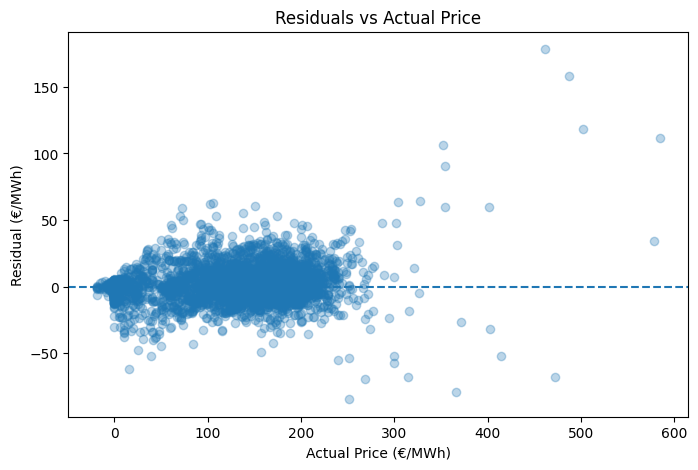

In [87]:

plt.figure(figsize=(8, 5))
plt.scatter(y_test_final, residuals_final, alpha=0.3)

plt.axhline(0, linestyle="--")

plt.xlabel("Actual Price (€/MWh)")
plt.ylabel("Residual (€/MWh)")
plt.title("Residuals vs Actual Price")

plt.show()

In [88]:
for lag in [1, 2, 4, 96, 672]:
    print(lag, residuals_final.autocorr(lag=lag))

1 0.060311935722296414
2 0.08223217084122854
4 0.44005204380406604
96 0.5154896245241455
672 0.444106666282703


### Residual Diagnostics

Residual autocorrelation was examined at the main temporal horizons used in
feature engineering.

| Lag | Time interval | Residual autocorrelation |
|---:|---|---:|
| 1 | 15 minutes | 0.060 |
| 2 | 30 minutes | 0.082 |
| 4 | 1 hour | 0.440 |
| 96 | 24 hours | 0.515 |
| 672 | 7 days | 0.444 |

Residual autocorrelation was weak at 15- and 30-minute lags, but substantially
higher at 1-hour, 24-hour, and 7-day lags.

This indicates that the linear model captures much of the very short-term
price persistence but leaves some systematic temporal structure unexplained.

The lag-feature experiments showed that adding `price_lag_4` did not provide
sufficient out-of-sample improvement to retain it. Therefore, the remaining
residual structure is not assumed to be solvable simply by adding every
autocorrelated lag as a predictor.

These diagnostics motivate testing a nonlinear model.

In [89]:
from sklearn.ensemble import GradientBoostingRegressor

model_gb = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

In [90]:
model_gb.fit(
    X_train_final,
    y_train_final
)

,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, in

In [91]:
y_pred_gb = model_gb.predict(X_test_final)

mae_gb = mean_absolute_error(
    y_test_final,
    y_pred_gb
)

rmse_gb = np.sqrt(
    mean_squared_error(y_test_final, y_pred_gb)
)

r2_gb = r2_score(
    y_test_final,
    y_pred_gb
)

print("Gradient Boosting Model")
print("MAE:", mae_gb)
print("RMSE:", rmse_gb)
print("R²:", r2_gb)

Gradient Boosting Model
MAE: 8.33453669432982
RMSE: 12.801311586965909
R²: 0.9652333153152686


### Gradient Boosting Baseline

A Gradient Boosting Regressor was introduced to test whether a nonlinear model
could improve upon the final linear regression model.

Using the same features and chronological test period:

| Model | MAE (€/MWh) | RMSE (€/MWh) | R² |
|---|---:|---:|---:|
| Linear Regression | 8.383 | 12.955 | 0.9644 |
| Gradient Boosting | 8.333 | 12.797 | 0.9653 |

The initial Gradient Boosting model produced a modest improvement across all
three metrics.

Because the improvement was small, further hyperparameter tuning will be used
to determine whether the nonlinear model can provide a more meaningful
performance gain.

## Hyperparameter Tuning

In [92]:
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=3)



In [93]:
gb = GradientBoostingRegressor(random_state=42)

param_grid = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.03, 0.05, 0.1],
    "max_depth": [2, 3, 4]
}

grid_search = GridSearchCV(
    estimator=gb,
    param_grid=param_grid,
    cv=tscv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

grid_search.fit(
    X_train_final,
    y_train_final
)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GradientBoost...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.03, 0.05, ...], 'max_depth': [2, 3, ...], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",TimeSeriesSpl...est_size=None)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable

In [94]:
print("Best parameters:", grid_search.best_params_)
print("Best CV MAE:", -grid_search.best_score_)

Best parameters: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 200}
Best CV MAE: 10.703562481621235


In [95]:
best_gb = grid_search.best_estimator_

best_gb.fit(
    X_train_final,
    y_train_final
)

,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",200
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",4
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, in

In [96]:
y_pred_best_gb = best_gb.predict(X_test_final)

mae_best_gb = mean_absolute_error(
    y_test_final,
    y_pred_best_gb
)

rmse_best_gb = np.sqrt(
    mean_squared_error(y_test_final, y_pred_best_gb)
)

r2_best_gb = r2_score(
    y_test_final,
    y_pred_best_gb
)

print("Tuned Gradient Boosting")
print("MAE:", mae_best_gb)
print("RMSE:", rmse_best_gb)
print("R²:", r2_best_gb)

Tuned Gradient Boosting
MAE: 8.251213396883395
RMSE: 12.647683555578421
R²: 0.9660627753126403


### Tuned Gradient Boosting Results

The Gradient Boosting model was tuned using time-series cross-validation on the
training data. The test set remained untouched during hyperparameter
selection.

The best parameters were:

- `learning_rate = 0.05`
- `max_depth = 4`
- `n_estimators = 200`

The tuned model was then evaluated on the held-out chronological test period.

| Model | MAE (€/MWh) | RMSE (€/MWh) | R² |
|---|---:|---:|---:|
| Linear Regression | 8.383 | 12.955 | 0.9644 |
| Gradient Boosting (baseline) | 8.333 | 12.797 | 0.9653 |
| Gradient Boosting (tuned) | 8.250 | 12.646 | 0.9661 |

The tuned Gradient Boosting model improved upon the final linear model across
all three evaluation metrics.

The improvement is modest rather than dramatic, but the tuned nonlinear model
provides the strongest predictive performance among the models tested.

In [97]:
comparison_df = pd.DataFrame({
    "actual": y_test_final.values,
    "linear_pred": y_pred_final,
    "gb_pred": y_pred_best_gb
})

In [98]:
comparison_df["linear_error"] = (
    comparison_df["actual"] - comparison_df["linear_pred"]
).abs()

comparison_df["gb_error"] = (
    comparison_df["actual"] - comparison_df["gb_pred"]
).abs()

In [99]:
spike_threshold = comparison_df["actual"].quantile(0.95)

spike_df = comparison_df[
    comparison_df["actual"] >= spike_threshold
].copy()

print("Spike threshold:", spike_threshold)
print("Number of spike observations:", len(spike_df))

Spike threshold: 212.86700000000005
Number of spike observations: 239


In [100]:
spike_linear_mae = spike_df["linear_error"].mean()
spike_gb_mae = spike_df["gb_error"].mean()

print("Linear MAE on high-price observations:", spike_linear_mae)
print("Gradient Boosting MAE on high-price observations:", spike_gb_mae)

Linear MAE on high-price observations: 18.819748871658433
Gradient Boosting MAE on high-price observations: 20.813965319209736


In [101]:
low_threshold = comparison_df["actual"].quantile(0.05)

low_df = comparison_df[
    comparison_df["actual"] <= low_threshold
].copy()

print("Low-price threshold:", low_threshold)
print("Number of low-price observations:", len(low_df))

Low-price threshold: -0.1
Number of low-price observations: 243


In [102]:
low_linear_mae = low_df["linear_error"].mean()
low_gb_mae = low_df["gb_error"].mean()

print("Linear MAE on low-price observations:", low_linear_mae)
print("Gradient Boosting MAE on low-price observations:", low_gb_mae)

Linear MAE on low-price observations: 2.154732477068284
Gradient Boosting MAE on low-price observations: 1.5653482831457777


### Error Analysis by Price Regime

Overall performance showed a modest improvement from Gradient Boosting, but
the improvement was not uniform across the price distribution.

The lowest and highest 5% of actual test-period prices were analyzed separately.

| Price region | Linear MAE (€/MWh) | Tuned Gradient Boosting MAE (€/MWh) |
|---|---:|---:|
| Lowest 5% | 2.155 | 1.565 |
| Highest 5% | 18.820 | 20.778 |

Tuned Gradient Boosting substantially reduced error for the lowest-price
observations, including periods with negative prices.

However, Linear Regression produced lower error for the highest-price
observations. Therefore, the nonlinear model did not eliminate the difficulty
of forecasting extreme upward price spikes.

This indicates that the overall improvement from Gradient Boosting is not
driven by better prediction of the highest-price events. Instead, the
nonlinear model provides better performance in other parts of the price
distribution.

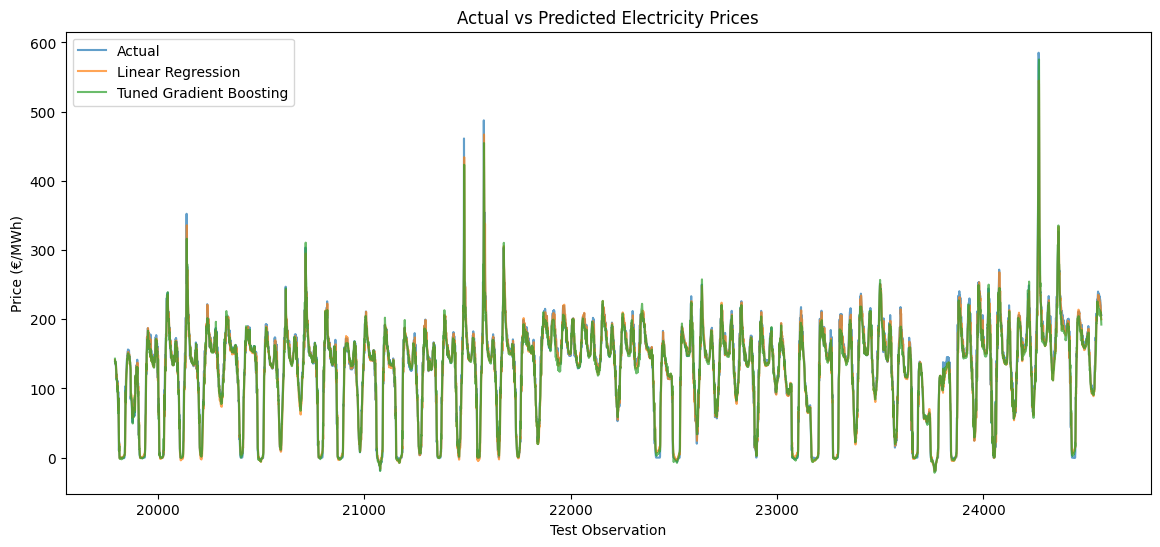

In [103]:
plt.figure(figsize=(14, 6))

plt.plot(
    y_test_final.index,
    y_test_final.values,
    label="Actual",
    alpha=0.7
)

plt.plot(
    y_test_final.index,
    y_pred_final,
    label="Linear Regression",
    alpha=0.7
)

plt.plot(
    y_test_final.index,
    y_pred_best_gb,
    label="Tuned Gradient Boosting",
    alpha=0.7
)

plt.xlabel("Test Observation")
plt.ylabel("Price (€/MWh)")
plt.title("Actual vs Predicted Electricity Prices")
plt.legend()
plt.show()

In [104]:
y_train_gb = model_gb.predict(X_train_final)
y_test_gb = model_gb.predict(X_test_final)

train_mae_gb = mean_absolute_error(y_train_final, y_train_gb)
test_mae_gb = mean_absolute_error(y_test_final, y_test_gb)

print("Train MAE:", train_mae_gb)
print("Test MAE:", test_mae_gb)

Train MAE: 7.129155428325939
Test MAE: 8.33453669432982


In [105]:
y_train_best_gb = best_gb.predict(X_train_final)
y_test_best_gb = best_gb.predict(X_test_final)

train_mae_best_gb = mean_absolute_error(
    y_train_final, y_train_best_gb
)

test_mae_best_gb = mean_absolute_error(
    y_test_final, y_test_best_gb
)

print("Train MAE:", train_mae_best_gb)
print("Test MAE:", test_mae_best_gb)

Train MAE: 6.566104433749497
Test MAE: 8.251213396883395


### Overfitting Check

Training and test MAE were compared for the Gradient Boosting models.

| Model | Train MAE (€/MWh) | Test MAE (€/MWh) |
|---|---:|---:|
| Gradient Boosting (baseline) | 7.129 | 8.333 |
| Gradient Boosting (tuned) | 6.566 | 8.250 |

The tuned model has a train-test MAE gap of approximately 1.68 €/MWh.

The tuned model shows a larger training-to-test gap than the baseline, but its
test-set MAE still improves from 8.333 to 8.250 €/MWh.

The results do not provide strong evidence of severe overfitting. The model
shows some expected generalization gap between training and unseen test data.

In [106]:
feature_importance = pd.Series(
    best_gb.feature_importances_,
    index=features_final
).sort_values(ascending=False)

print(feature_importance)

price_lag_1      0.969897
price_lag_96     0.009184
wind_onshore     0.005313
solar            0.004960
hour_sin         0.004854
price_lag_672    0.003579
load             0.001563
hour_cos         0.000490
day_5            0.000065
day_2            0.000030
day_1            0.000026
day_6            0.000024
day_4            0.000010
day_3            0.000006
dtype: float64


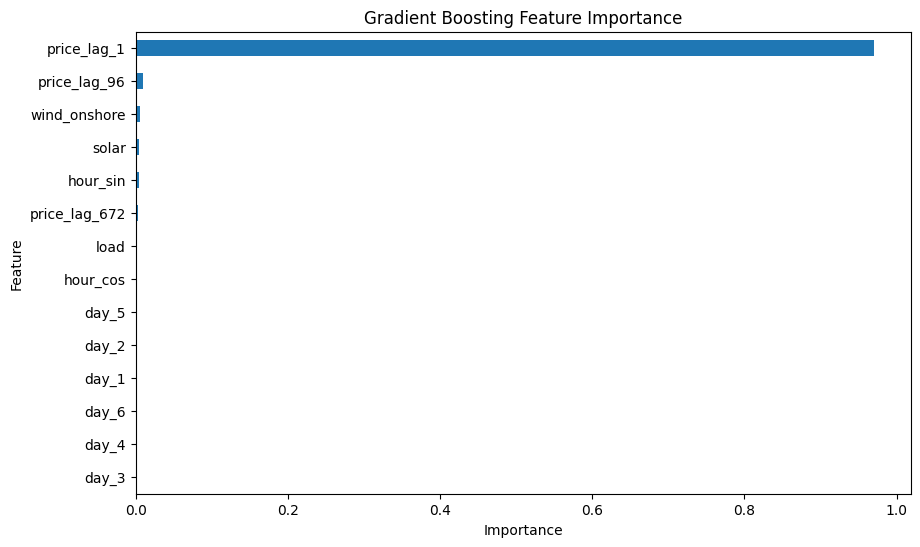

In [107]:
plt.figure(figsize=(10, 6))

feature_importance.sort_values().plot(kind="barh")

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Gradient Boosting Feature Importance")

plt.show()

### Gradient Boosting Feature Importance

The tuned Gradient Boosting model assigned the highest importance to
`price_lag_1`, with an importance of approximately 0.970.

The 24-hour lag (`price_lag_96`) contributed about 0.009, while wind,
solar, hour-of-day features, the 7-day lag, load, and weekday indicators
had substantially smaller individual importances.

This indicates that the model's predictions are dominated by recent price
history, with the other variables providing smaller incremental information.

Feature importance represents how much the fitted model uses each feature
for prediction; it should not be interpreted as a causal effect.

In [108]:
baseline_pred_final = X_test_final["price_lag_1"]

mae_baseline_final = mean_absolute_error(
    y_test_final,
    baseline_pred_final
)

rmse_baseline_final = np.sqrt(
    mean_squared_error(y_test_final, baseline_pred_final)
)

r2_baseline_final = r2_score(
    y_test_final,
    baseline_pred_final
)

print("Persistence Baseline")
print("MAE:", mae_baseline_final)
print("RMSE:", rmse_baseline_final)
print("R²:", r2_baseline_final)

Persistence Baseline
MAE: 9.011435146443516
RMSE: 14.059450851390954
R²: 0.9580636085501218


### Final Model Comparison

The final models were evaluated on the same chronological test period.

| Model | MAE (€/MWh) | RMSE (€/MWh) | R² |
|---|---:|---:|---:|
| Persistence Baseline | 9.011 | 14.059 | 0.9581 |
| Linear Regression | 8.383 | 12.955 | 0.9644 |
| Gradient Boosting (baseline) | 8.333 | 12.797 | 0.9653 |
| Gradient Boosting (tuned) | 8.250 | 12.646 | 0.9661 |

The tuned Gradient Boosting model achieved the lowest MAE and RMSE and the
highest R² among the models evaluated.

Compared with the persistence baseline, the tuned model reduced MAE by
approximately 8.45% and RMSE by approximately 10.05%.

The improvement is meaningful but not dramatic, indicating that recent price
persistence explains a large part of short-term price behaviour.

## Final Conclusions

This project examined German day-ahead electricity prices from January 1
through September 13, 2026, focusing on the relationship between electricity
demand, renewable generation, and price, and on short-term price prediction.

### Key Findings

- Renewable generation showed a strong negative linear association with
  electricity price (r = -0.72), while overall load-price correlation was
  weakly positive (r = 0.11).
- The load-price relationship varied substantially by hour of day, indicating
  that time-of-day effects are important when interpreting simple correlations.
- Short-term price persistence was the strongest predictive signal. The
  previous 15-minute price (`price_lag_1`) was the dominant feature in the
  Gradient Boosting model.
- Adding the 24-hour lag improved predictive performance, and the 7-day lag
  provided a further improvement.
- Adding 30-minute and 1-hour lags did not provide sufficient incremental
  improvement and they were excluded from the selected feature set.
- Weekday indicators further improved the linear model. Month-of-year was not
  evaluated because the dataset covers only January through September.

### Model Results

The tuned Gradient Boosting model achieved:

- MAE: 8.250 €/MWh
- RMSE: 12.646 €/MWh
- R²: 0.9661

Compared with the persistence baseline, the tuned model reduced MAE by
approximately 8.45% and RMSE by approximately 10.05%.

### Model Interpretation

The improvement from Gradient Boosting over Linear Regression was modest
rather than dramatic. Error analysis showed that Gradient Boosting performed
better for the lowest 5% of prices but was less accurate for the highest 5%.

Therefore, the tuned Gradient Boosting model should not be interpreted as
reliably forecasting extreme upward price spikes.

Feature importance showed that the previous 15-minute price (`price_lag_1`)
was by far the most heavily used feature, while the 24-hour and 7-day lags,
renewable generation, load, time-of-day, and weekday features provided much
smaller additional contributions.

Overall, the results indicate that recent price persistence explains a large
portion of short-term price behaviour, while the additional demand, renewable
generation, temporal, and calendar variables provide incremental predictive
information.

### Limitations

- The dataset covers less than one full year, limiting analysis of annual
  seasonality.
- The final models were evaluated using a single chronological train/test
  split, while time-series cross-validation was used during Gradient Boosting
  hyperparameter tuning.
- Feature importance describes model usage, not causal effects.
- Extreme upward price events remain difficult to predict accurately.